# Goals for Exploration
* Find any missing/strange data.
* Figure out how to handle returns/negative quantity.

# Cohort Analysis
* Grouping: First purchase month

# Preparation
* Create quintiles for Recency, Frequency, and Monetary Value

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
df1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
df2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([df1, df2])

# Cleaning and Filtering
* Removed rows where Customer IDs are missing because they are not relevant. Many are also just instances of inventory being thrown away or something similar.
* Returns (negative quantity entries) will not be counted for time-based metrics like retention and purchase frequency, however they will be included for revenue.

In [3]:
df = df[pd.notna(df['Customer ID'])]
df['Revenue'] = df['Price'] * df['Quantity']

# Cohort Analysis

I need to set up the Cohort Analysis by creating a column for the first month of purchase, frequency of purchasing, and spending per order.

For the first month of purchase, I'll need to manipulate the dates so I can grab just the year and month (to be stored as 'InvoiceMonth') since they also include the day and time. Then, I will have to find the earliest month of purchase based on the months/years that will be stored as 'CohortMonth'. From there I will create an index for each cohort based on how many months it has been since their first purchase. 

I will also remove any refunds (Quantity < 0) so they do not appear in the heat map later on.


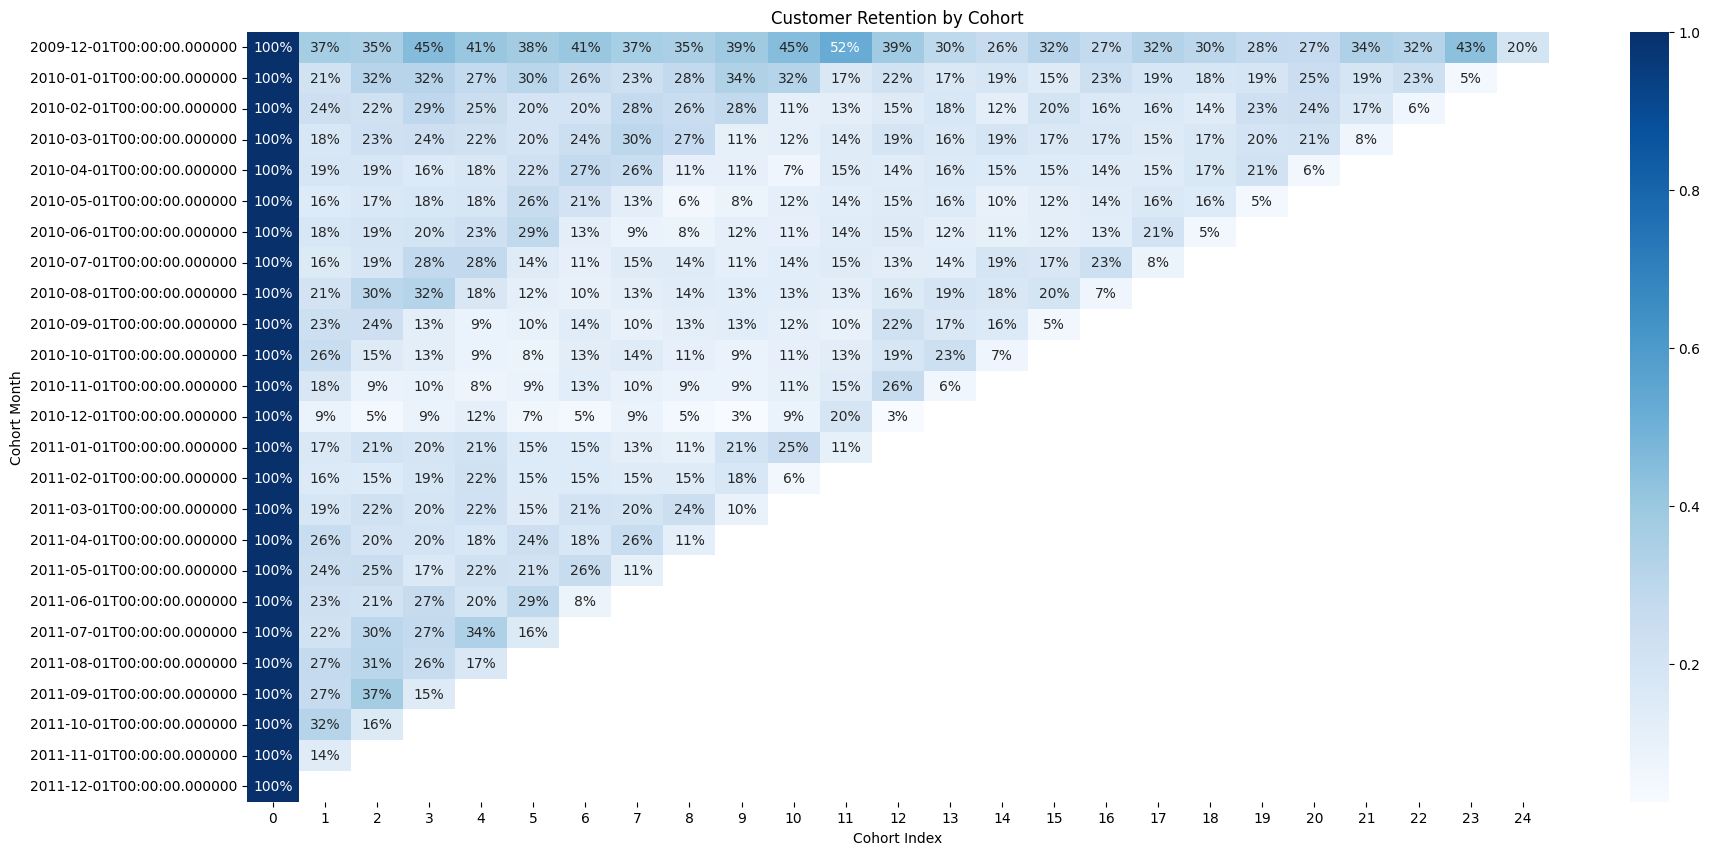

In [4]:
import datetime as dt

def get_month(date):
    # grabs the month and year for all of a month's invoices to be consolidated into the first day of the month
    return dt.datetime(date.year, date.month, 1)

df['Invoice Month'] = df['InvoiceDate'].apply(get_month)
df['Cohort Month'] = df.groupby('Customer ID')['Invoice Month'].transform('min')

def adjust_months(days):
    # Arbitrarily decides if the days are close enough to be rounded up to the next month
    # 30 is arbitrarily chose to be a month (there is not real objective month timeframe), and 20 is also arbitrarily chosen because it's close-ish to 30.
    # 20 can really be any number
    months, remainder = divmod(days,30)
    if remainder >= 20:
        return months + 1
    else:
        return months
    
def get_time_delta(df, column1, column2):
    # After a simple subtraction, use adjust_months to determine if the remainder is close enough to a full month to round
    days = (df[column1] - df[column2]).dt.days
    adjusted_months = days.map(adjust_months)
    return adjusted_months

adjusted_months = get_time_delta(df, 'Invoice Month', 'Cohort Month')
df['Cohort Index'] = adjusted_months

#Cohort Heat map
cohort_data = df[df['Quantity'] > 0].groupby(['Cohort Month','Cohort Index'])['Customer ID'].apply(pd.Series.nunique).reset_index()
cohort_table = cohort_data.pivot(index='Cohort Month', columns=['Cohort Index'],values='Customer ID')
cohort_table = cohort_table.divide(cohort_table.iloc[:,0], axis=0)
plt.figure(figsize=(21,10))
sns.heatmap(cohort_table,annot=True,fmt='.0%', cmap='Blues')
plt.title("Customer Retention by Cohort")
plt.savefig('Images/CohortAnalysis.png')

There are some interesting points:
* The first cohort is especially consistent.
* There is a strange parallelogram with a base at the 2010-12-01 00:00:00 cohort where there is a noticeable decrease in consistency (between 0 and 20%), which the cohorts eventually recovered from to get to the 20-30% retention rate that is more typical for other cohorts. Even weirder, the cohorts after do not even seem to have this effect at all.
* The last entry is lower than expected because the data does not extend to December 31st, and in fact ends on December 9th. So, the values are expected to be around three times higher.

Some things to do:
* Look at the 2009-12-01 00:00:00 and 2010-12-01 00:00:00 cohorts to see if there is anything strange about it. The former is especially loyal, and the latter is especially sporadic.
* Look into the downturn in activity by older cohorts from January to October 2011.

## Downturn from January to October 2011 for previous customers
The "Parallelogram", the period of low activity for previous customers, is interesting because it does not extend to future clients which means it likely isn't economic conditions. This includes the well scoring cohorts from the start of 2010, though the quality of the cohorts was generally decreasing until February 2011.

I want to look at a few things during this time period:
* Price and how it compares to the mode price for the items sold.
* Look at revenue compared to number of invoices and compare that to January to December 2010.

In [5]:
control_dates = df['Invoice Month'].unique()[3:13]
downturn_dates = df['Invoice Month'].unique()[13:23]

control_df = df[df['Invoice Month'].isin(control_dates)]
downturn_df = df[df['Invoice Month'].isin(downturn_dates)]

(1 - (control_df.shape[0] / downturn_df.shape[0])) * 100

-23.44263952547856

In [6]:
(1- (control_df['Invoice'].nunique() / downturn_df['Invoice'].nunique())) * 100

-20.564491654021253

In [7]:
(1- (control_df['Quantity'].nunique() / downturn_df['Quantity'].nunique())) * 100

-13.846153846153841

In [8]:
(1- (control_df['Revenue'].nunique() / downturn_df['Revenue'].nunique())) * 100

5.981201936770153

In [9]:
(np.float64(1) - (control_df['Price'].mean() / downturn_df['Price'].mean())) * 100

np.float64(-6.560579372151931)

In [10]:
(1 - (control_df.groupby(['Invoice'])['Revenue'].sum().mean() / downturn_df.groupby(['Invoice'])['Revenue'].sum().mean())) * 100

np.float64(4.522003075355629)

We see a 20.5% decrease in invoices, ~14% decrease in quantity, 6.5% decrease in price paid but ~6% increase in Revenue and a 4.5% increase in revenue per invoice. It is possible that the discrepancy is due to some sort of pressure influencing customers to act a certain way. 

A price analysis is intended to try to see if one reason is valid: the price paid was higher or equal to the mode price rather than lower. Not having as many sales could have led to fewer orders which generated more revenue.

In [11]:
item_prices = df.groupby('Description')['Price'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)

control_price_cmp = control_df.copy()
control_price_cmp['Mode Price'] = control_price_cmp['Description'].map(item_prices).astype(float)

control_price_cmp['Price vs Mode'] = np.select(
    [control_price_cmp['Price'] > control_price_cmp['Mode Price'],
     control_price_cmp['Price'] == control_price_cmp['Mode Price']],
    ['more', 'equal'],
    default='less'
)

comparison_summary = control_price_cmp['Price vs Mode'].value_counts().rename_axis('Comparison').reset_index(name='Count')
comparison_summary['Percent'] = (comparison_summary['Count'] / comparison_summary['Count'].sum() * 100).round(2)
comparison_summary

,Comparison,Count,Percent
0,equal,329590,89.98
1,less,29384,8.02
2,more,7305,1.99


In [12]:
item_prices = df.groupby('Description')['Price'].agg(lambda x: x.mode().iat[0] if not x.mode().empty else np.nan)

downturn_price_cmp = downturn_df.copy()
downturn_price_cmp['Mode Price'] = downturn_price_cmp['Description'].map(item_prices).astype(float)

downturn_price_cmp['Price vs Mode'] = np.select(
    [downturn_price_cmp['Price'] > downturn_price_cmp['Mode Price'],
     downturn_price_cmp['Price'] == downturn_price_cmp['Mode Price']],
    ['more', 'equal'],
    default='less'
)

comparison_summary = downturn_price_cmp['Price vs Mode'].value_counts().rename_axis('Comparison').reset_index(name='Count')
comparison_summary['Percent'] = (comparison_summary['Count'] / comparison_summary['Count'].sum() * 100).round(2)
comparison_summary

,Comparison,Count,Percent
0,equal,256057,86.30
1,less,23401,7.89
2,more,17262,5.82


We can see a noticeable uptick in prices going above the modal price (2% to ~6%) which mostly comes out of equal pricing.

## RFM Analysis
I want to establish quintiles (arbitrary, but the Investopedia article suggested quintiles) for RFM (recency, frequency, and monetary value).

Recency is just the days since the last purchase. Frequency is the toal number of invoices, and monetary value is the total revenue generated.

This should provide some insights into customers and cohorts alike.


In [13]:
recency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].max()
recency.columns = ['Customer ID', 'Last Purchase Date']
last_date = recency['Last Purchase Date'].max()
recency['Recency'] = recency['Last Purchase Date'].apply(lambda x: (last_date - x).days)

frequency = df.groupby(by='Customer ID', as_index=False)['InvoiceDate'].count()
frequency.columns = ['Customer ID', 'Frequency']

monetary_value = df.groupby(by='Customer ID', as_index=False)['Revenue'].sum()
monetary_value.columns = ['Customer ID', 'Monetary Value']

rf_df = recency.merge(frequency, on='Customer ID')
rfm_df = rf_df.merge(monetary_value, on='Customer ID').drop(columns='Last Purchase Date')

rfm_df['Recency Quintile'] = pd.qcut(x=rfm_df['Recency'], q=5, labels=[5,4,3,2,1]).astype(np.int64)
rfm_df['Frequency Quintile'] = pd.qcut(x=rfm_df['Frequency'], q=5, labels=[1,2,3,4,5]).astype(np.int64)
rfm_df['Monetary Value Quintile'] = pd.qcut(x=rfm_df['Monetary Value'], q=5, labels=[1,2,3,4,5]).astype(np.int64)

rfm_df['Avg RFM Score'] = ((rfm_df['Recency Quintile'] + rfm_df['Frequency Quintile'] + rfm_df['Monetary Value Quintile']) / 3).round(2)
rfm_df.drop(["Recency", "Frequency", "Monetary Value"], axis=1)


,Customer ID,Recency Quintile,Frequency Quintile,Monetary Value Quintile,Avg RFM Score
0,12346.0,2,3,1,2.00
1,12347.0,5,5,5,5.00
2,12348.0,3,3,4,3.33
3,12349.0,4,4,5,4.33
4,12350.0,2,2,2,2.00
...,...,...,...,...,...
5937,18283.0,5,5,4,4.67
5938,18284.0,1,2,2,1.67
5939,18285.0,1,1,2,1.33
5940,18286.0,1,3,4,2.67


In [14]:
rfm_df["Customer Segment"] = np.where(rfm_df['Avg RFM Score'] >= 4.5, "Top Customers",
                                np.where(rfm_df['Avg RFM Score'] >= 4, "High Value Customers",
                                    np.where(rfm_df['Avg RFM Score'] >= 3, "Medium Value Customers",
                                        np.where(rfm_df['Avg RFM Score'] >= 2, 'Low Value Customers','Lost Customers'))))

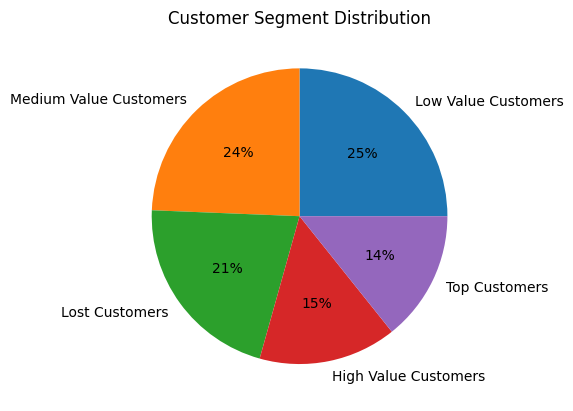

In [15]:
plt.pie(rfm_df["Customer Segment"].value_counts(), labels = rfm_df["Customer Segment"].value_counts().index,autopct='%.0f%%')
plt.title("Customer Segment Distribution")
plt.savefig('Images/CustomerSegments.png')

## Cohort Analysis by RFM

The spread of customer segments is fairly even and it's really surprising that the top two categories have around 30% of the total. I'd have expected it to be much lower. 

With some insight into the customer base as a whole, it's time to apply FRM analysis to cohorts, partly to explain the divide between the December 2009 and 2010 cohorts, and to see if there are any other trends.

In [16]:
cohort_2009_12_df = df[df['Cohort Month'] == '2009-12-01 00:00:00']
cohort_2010_12_df = df[df['Cohort Month'] == '2010-12-01 00:00:00']

In [17]:
unique_customers_2009 = cohort_2009_12_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
rfm_cohort_2009_12_df = rfm_df.merge(right=unique_customers_2009,how='inner')
rfm_cohort_2009_12_df['Avg RFM Score'].mean()

np.float64(3.680842105263158)

In [18]:
unique_customers_2010 = cohort_2010_12_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
rfm_cohort_2010_12_df = rfm_df.merge(right=unique_customers_2010,how='inner')
rfm_cohort_2010_12_df['Avg RFM Score'].mean()

np.float64(2.6358441558441563)

There is substantial difference between the poorly performing cohort (2010-12) and the incredibly loyal (2009-12) cohort. Which is interesting and brings up the question of how do the cohorts rank in terms of average RFM score?

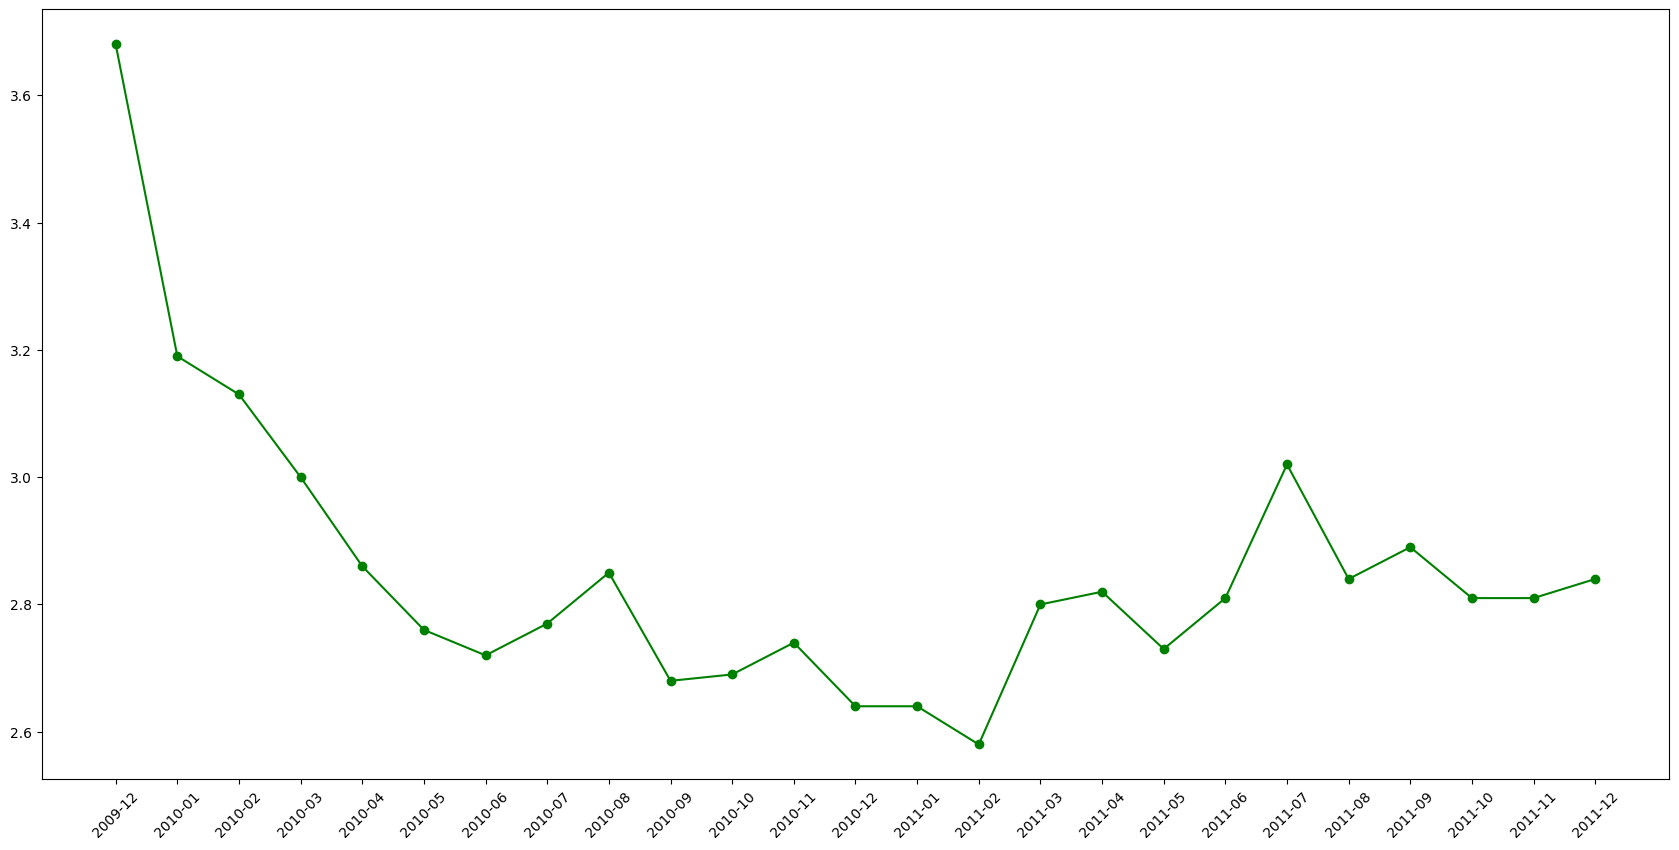

In [19]:
rfm_avg_dict = {}
for cohort in df['Cohort Month'].drop_duplicates():
    cohort_df = df[df['Cohort Month'] == cohort]
    unique_customers = cohort_df['Customer ID'].drop_duplicates().reset_index().drop(columns='index')
    rfm_cohort = rfm_df.merge(right=unique_customers,how='inner')
    rfm_avg_dict[str(cohort)[:7]]= rfm_cohort['Avg RFM Score'].mean().round(2)

plt.figure(figsize=(21,10))
plt.xticks(rotation=45)
plt.plot(rfm_avg_dict.keys(), rfm_avg_dict.values(), color='green', marker='o')


## Conclusions
Interestingly, 2010-12 was not even the lowest average RFM score, but it is among the lowest. The reason for this is likely because I gave each factor equal weight, but differing weights could capture this better and reflect reality more.

Regardless, this gives some insight into why certain cohorts seem better than other ones. The initial cohort does seem to be the best by a large margin, and the 2010-12 cohort is among the worst cohorts by this metric. It also showcases some trends for cohorts where they are lower quality on average (for example from September 2010 to February 2011), and others are better such as the period from July 2011 to the present.

### Business Insights
There were a few things of note:
* There are plenty of higher value customers to cater to which can easily sustain the business.
* The down-tick in activity from January to October 2011 is likely from an uptick in above-mode pricing, which led to significantly fewer sales but an uptick in revenue.
* There are trends among periods of time where cohorts are lower or higher value than average. Looking into this point and the previous one would be beneficial.
